In [1]:
import pandas as pd
import numpy as np
import json
import re
import snowflake.connector
from sqlalchemy import create_engine, text
from snowflake.sqlalchemy import URL
from datetime import datetime, timedelta, timezone

In [2]:
url = URL(
    user='BITEAM',
    password='B1sense@22',
    account='YXBYZCG-MVA06208',
    database="DBT_PROD.PUBLIC",
)
engine = create_engine(url)
connection = engine.connect()

In [3]:
query = '''

with leads_tb as(
select 
jluvr,
raw_request_json,
request_datetime,
seller_name,
seller_minimum_price,
TRY_PARSE_JSON(raw_request_json):leadIpAddress::string AS lead_ip_address,
case 
    when id_campaign = 11 then 948015
    when id_campaign = 1017 then 948017
    when id_campaign = 1018 then 948018
    when id_campaign = 1019 then 948019
    else 999999
end as partner_id,
from  DBT_PROD.ANALYTICS.fct_ping_seller_api_transaction as leads
where request_type = 'lead_post'
and request_date > '2025-12-01' and request_date < '2026-02-22'
),

order_tb as (
select *,
ROW_NUMBER() OVER(PARTITION BY jluvr ORDER BY order_id DESC) as rownum				
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where order_date > '2025-11-01' and order_date < '2026-03-15' and signup_type like '%initial%'
),


jluvr_tb as (
select 
jluvr,
max(order_id) as order_id,
max(order_status) as order_status,
max(cascade_type) as cascade_type
from order_tb
where rownum = 1
group by 1
),

ip_tb as (
select
distinct 
order_id,
partner_id,
customer_ip,
order_status
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where order_date > '2025-10-01' and order_date < '2026-03-15' and signup_type like '%initial%'
),

final as (
select 
leads_tb.*,
COALESCE(jluvr_tb.order_id, ip_tb.order_id) as order_id,
jluvr_tb.order_status,
jluvr_tb.cascade_type,
case
when COALESCE(jluvr_tb.order_status, ip_tb.order_status) = 'success' then 'm0'
else 'unknown'
end as label
from leads_tb
left join jluvr_tb using (jluvr)
left join ip_tb
on ip_tb.customer_ip = leads_tb.lead_ip_address
and ip_tb.partner_id = leads_tb.partner_id
)

select * from final
'''

In [4]:
with engine.connect() as con:
    con.execute(text("use database dbt_prod"))
    df = pd.read_sql(query, con)

In [5]:
len(df)

1611159

In [6]:
import pandas as pd
import json
import re
from typing import Optional, List

def camel_to_snake(name: str) -> str:
    """Convert camelCase or PascalCase string to snake_case."""
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1)
    return s2.lower()

def expand_json_column(
    df: pd.DataFrame,
    json_col: str,
    snake_case: bool = True,
    parse_dates: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    Expand a JSON column into separate columns, optionally convert to snake_case,
    and parse datetime columns. Drops any columns from df that overlap with the
    expanded JSON keys to avoid duplicates.
    """
    # Function to safely convert a value to dict
    def to_dict(x):
        if pd.isna(x):
            return {}
        if isinstance(x, dict):
            return x
        try:
            return json.loads(x)
        except Exception:
            return {}

    # Expand JSON column
    dicts = df[json_col].apply(to_dict)
    normalized = pd.json_normalize(dicts)

    # Convert column names to snake_case if requested
    if snake_case:
        normalized.columns = [camel_to_snake(c) for c in normalized.columns]

    # Drop overlapping columns in original df to prevent duplicates
    overlap_cols = [c for c in normalized.columns if c in df.columns]
    if overlap_cols:
        df = df.drop(columns=overlap_cols)

    # Parse datetime columns if requested
    if parse_dates:
        for col in parse_dates:
            if col in normalized.columns:
                normalized[col] = pd.to_datetime(normalized[col], errors='coerce')

    # Concatenate the expanded JSON columns with the rest of the DataFrame
    out = pd.concat([df.drop(columns=[json_col]), normalized], axis=1)

    return out


In [7]:
expanded_1 = expand_json_column(df, "raw_request_json", snake_case=True, parse_dates=["request_datetime"])

In [8]:
import re

def to_snake(col):
    # Remove leading/trailing spaces
    col = col.strip()
    # Replace multiple spaces with single underscore
    col = re.sub(r"\s+", "_", col)
    # Insert underscores before capital letters that follow lowercase letters
    col = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", col)
    # Lowercase
    return col.lower()

expanded_1.columns = [to_snake(c) for c in expanded_1.columns]

In [9]:
pd.set_option('display.max_columns', None)

In [10]:
expanded_1.columns

Index(['request_datetime', 'seller_name', 'partner_id', 'order_id',
       'order_status', 'cascade_type', 'label', 'jluvr', 'campaign_id',
       'campaign_adid', 'seller_id', 'seller_sub1', 'seller_sub2',
       'seller_sub3', 'seller_unique_lead_id', 'seller_minimum_price',
       'lead_creation_url', 'lead_referring_url', 'lead_user_agent',
       'lead_ip_address', 'lead_creation_time', 'applicant_email',
       'applicant_mobile_phone', 'loan_amount', 'loan_purpose',
       'finance_current_unsecured_debt_amount',
       'finance_have_checking_account', 'finance_credit_rating',
       'applicant_employment_type', 'applicant_job_title',
       'applicant_employer_name', 'applicant_employment_length',
       'applicant_income_payment_type', 'applicant_income_pay_frequency',
       'applicant_income_net_monthly_amount', 'applicant_income_last_pay_day',
       'applicant_income_next_pay_day', 'applicant_income_following_pay_day',
       'applicant_first_name', 'applicant_lastname', '

In [11]:
len(expanded_1)

1611159

In [12]:
expanded_1.consent_marketing_email

0            NaN
1           True
2           True
3           True
4           True
           ...  
1611154     True
1611155    False
1611156    False
1611157     True
1611158     True
Name: consent_marketing_email, Length: 1611159, dtype: object

In [13]:
columns_to_keep = ['order_id','request_datetime','seller_name','label','seller_minimum_price','lead_user_agent','loan_amount',
                   'loan_purpose', 'finance_current_unsecured_debt_amount', 'applicant_employment_type',
                   'applicant_income_net_monthly_amount','applicant_employment_length','applicant_income_last_pay_day',
                   'applicant_income_next_pay_day', 'applicant_date_of_birth', 'applicant_current_address_state',
                   'applicant_current_address_residence_status', 'applicant_current_address_years',
                   'bank_account_bank_name','bank_account_years','lead_creation_url','campaign_id',
                   'consent_marketing_email']

In [14]:
expanded = expanded_1[columns_to_keep] 

expanded = expanded.dropna(subset=['seller_name'])

expanded = expanded.dropna(subset=['seller_minimum_price'])

expanded = expanded.dropna(subset=['applicant_income_last_pay_day'])

In [15]:
expanded.isnull().sum()

order_id                                      1422075
request_datetime                                    0
seller_name                                         0
label                                               0
seller_minimum_price                                0
lead_user_agent                                     0
loan_amount                                         0
loan_purpose                                        0
finance_current_unsecured_debt_amount          379890
applicant_employment_type                           0
applicant_income_net_monthly_amount                 0
applicant_employment_length                   1151099
applicant_income_last_pay_day                       0
applicant_income_next_pay_day                       0
applicant_date_of_birth                             0
applicant_current_address_state                     0
applicant_current_address_residence_status          0
applicant_current_address_years                     0
bank_account_bank_name      

In [16]:
# 1. Fill Numeric Columns with integer -1
# This covers floats and integers
num_cols = expanded.select_dtypes(include=['number']).columns
expanded[num_cols] = expanded[num_cols].fillna(-1)

# 2. Fill String/Object Columns with string "-1"
# This prevents mixed-type errors later
obj_cols = expanded.select_dtypes(include=['object']).columns
expanded[obj_cols] = expanded[obj_cols].fillna('unknown')


/var/folders/46/cr7dgrkj6wg5rb247mcvnzz40000gp/T/ipykernel_22851/3808044701.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  expanded[obj_cols] = expanded[obj_cols].fillna('unknown')


In [17]:
# Assuming your dataframe is named 'expanded' or 'df'
expanded['campaign_id'] = expanded['campaign_id'].astype('Int64').astype(str)

In [18]:
# applicant_employer_name can be droppedd. Mostly are pension/benefits 
#expanded.groupby(by = 'applicant_employment_length').count().sort_values(by = 'request_datetime', ascending = False).head(5)

In [19]:
#expanded.groupby(by = 'lead_user_agent').count().sort_values(by = 'request_datetime', ascending = False).head(20)

In [20]:
sample_size_df = expanded[(expanded['request_datetime'] > '2026-02-03') & (expanded['request_datetime'] < '2026-02-22')]#.sample(n=250000, random_state=42)

In [21]:
expanded.columns

Index(['order_id', 'request_datetime', 'seller_name', 'label',
       'seller_minimum_price', 'lead_user_agent', 'loan_amount',
       'loan_purpose', 'finance_current_unsecured_debt_amount',
       'applicant_employment_type', 'applicant_income_net_monthly_amount',
       'applicant_employment_length', 'applicant_income_last_pay_day',
       'applicant_income_next_pay_day', 'applicant_date_of_birth',
       'applicant_current_address_state',
       'applicant_current_address_residence_status',
       'applicant_current_address_years', 'bank_account_bank_name',
       'bank_account_years', 'lead_creation_url', 'campaign_id',
       'consent_marketing_email'],
      dtype='object')

In [22]:
expanded_1['cascade_type']= expanded_1['cascade_type'].fillna('Core')

In [23]:
expanded_1[['label','cascade_type', 'order_id']].groupby(by = ['cascade_type', 'label']).count()

order_id
cascade_type label            
Core         m0          77741
             unknown      3121
blacklist    m0             11
             unknown      5443
casB         m0          32409
             unknown       745
casD         m0          23873
             unknown       168
casP         m0          44941
             unknown       594

In [24]:
1-(74517/(74517+32266+23666+44845))

0.5749027348340503

## Data Cleaning - Categorization

In [26]:
# def get_lead_user_agent(lead_user_agent: str) -> str:
#     name = lead_user_agent if lead_user_agent else ""
#     if name == 'Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/18.6 Mobile/15E148 Safari/604.1':
#         return "lead_agent_1"
#     elif name == 'Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Mobile Safari/537.36':
#         return "lead_agent_2"
#     else:
#         return "others"
# expanded["lead_user_agent"] = expanded["lead_user_agent"].apply(get_lead_user_agent) 

In [27]:
expanded.loan_purpose.unique()

array(['emergency', 'MedicalExpense', 'OneOffPurchase', 'CarRepair',
       'other', 'DebtConsolidation', 'ShortTermCash', 'Other',
       'home_improvement', 'UnexpectedExpense', 'Presents',
       'HouseholdBills', 'Holiday', 'PayOffLoan', 'CelebrationMajorEvent',
       'Subsistence', 'HomeImprovements', 'CarLoan',
       'HouseholdPersonalGoods', 'PayBills'], dtype=object)

In [28]:
# def get_loan_purpose(loan_purpose: str) -> str:
#     name = loan_purpose if loan_purpose else ""
#     if name in ('Holiday', 'CelebrationMajorEvent', 'Presents'):
#         return 'celebration'
#     elif name in ('DebtConsolidation', 'PayOffLoan','CarLoan'):
#         return 'debt'
#     elif name in ('emergency', 'ShortTermCash','UnexpectedExpense','CarRepair','MedicalExpense'):
#         return 'emergency'
#     elif name in ('HomeImprovements','HouseholdBills','HouseholdPersonalGoods','OneOffPurchase','home_improvement','PayBills','Subsistence'):
#         return 'Bills'
#     else:
#         return 'others'
# expanded["loan_purpose"] = expanded["loan_purpose"].apply(get_loan_purpose)

In [29]:
def get_bank_name(bank_account_bank_name: str) -> str:
    name = bank_account_bank_name.lower() if bank_account_bank_name else ""
    if "bancorp" in name:
        return "bancorp"
    elif "sutton" in name:
        return "sutton"
    elif "stride" in name:
        return "stride"
    elif "wells fargo" in name:
        return "wells_fargo"
    elif "chase" in name:
        return "chase"
    elif "bank of america" in name:
        return "bank_of_america"
    else:
        return "others"
        
expanded["bank_name"] = expanded["bank_account_bank_name"].apply(get_bank_name)

In [30]:
def get_resident_status(applicant_current_address_residence_status: str) -> str:
    name = applicant_current_address_residence_status.lower() if applicant_current_address_residence_status else ""
    if "rent" in name:
        return "rent"
    elif "own" in name:
        return "own"
    else:
        return "others"
        
expanded["resident_status"] = expanded["applicant_current_address_residence_status"].apply(get_resident_status)

In [31]:
def get_employment_type(applicant_employment_type: str) -> str:
    name = applicant_employment_type.lower() if applicant_employment_type else ""
    if "full" in name:
        return "full_time"
    elif "benefit" in name:
        return "benefit"
    elif "pension" in name:
        return "benefit"
    elif "part" in name:
        return "part_time"
    else:
        return "others"
        
expanded["applicant_employment_type"] = expanded["applicant_employment_type"].apply(get_employment_type)

In [32]:
def get_device_type(lead_user_agent: str) -> str:
    name = lead_user_agent.lower() if lead_user_agent else ""
    if "iphone" in name:
        return "apple_mobile"
    elif "android" in name:
        return "not_apple_mobile"
    elif "macintosh" in name:
        return "apple_desktop"
    elif "windows" in name or "x11" in name:
        return "not_apple_desktop"
    elif "ipad" in name:
        return "apple_tablet"
    else:
        return 'others'
        
expanded["lead_user_agent"] = expanded["lead_user_agent"].apply(get_device_type) 

In [33]:
expanded['is_apple_device'] = np.where(
    expanded['lead_user_agent'].str.contains('apple', case=False, na=False), 
    1, 
    0
)

expanded['is_mobile_device'] = np.where(
    expanded['lead_user_agent'].str.contains('mobile', case=False, na=False), 
    1, 
    0
)

In [34]:
US_STATES = (
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'
)

def get_states(code: str) -> str:
    # Handle None/NaN safety
    if not code:
        return 'others'
        
    name = code
    
    # Now 'US_STATES' refers to the global list, 'name' refers to the input 
    if name in US_STATES:
        return name
    else:
        return 'others'
expanded['applicant_current_address_state'] = expanded['applicant_current_address_state'].str[:2].str.upper()
expanded['state'] = expanded["applicant_current_address_state"].apply(get_states)

In [35]:
# Get age
expanded['applicant_date_of_birth'] = pd.to_datetime(expanded['applicant_date_of_birth'], errors='coerce')
expanded['age'] = (pd.Timestamp.now() - expanded['applicant_date_of_birth']).dt.days // 365.25


expanded['is_under_30'] = (expanded['age'] < 30).astype(int)
expanded['loan_to_age_ratio'] = expanded['loan_amount'] / expanded['age']
expanded['income_to_age_ratio'] =expanded['applicant_income_net_monthly_amount'] / expanded['age']

In [36]:
# Get days till next pay
next_pay_date = pd.to_datetime(expanded['applicant_income_next_pay_day'], errors='coerce')
request_date = pd.to_datetime(expanded['request_datetime'], errors='coerce')

next_pay_date = next_pay_date.dt.tz_localize(None)
request_date = request_date.dt.tz_localize(None)

next_pay_date = next_pay_date.dt.normalize()
request_date = request_date.dt.normalize()

expanded['days_till_next_pay'] = (next_pay_date - request_date).dt.days

In [37]:
# Get loan to income ratio
expanded['loan_to_income_ratio'] =expanded['loan_amount'] / expanded['applicant_income_net_monthly_amount']

In [38]:
# Assuming you already converted request_datetime to datetime objects
expanded['lead_hour_of_day'] = expanded['request_datetime'].dt.hour

def get_time_period(lead_hour_of_day: str) -> str:
    time = lead_hour_of_day if lead_hour_of_day else ""
    if time in range(21,24):
        return 1
    if time in range(0,5):
        return 1
    else:
        return 0

expanded['is_late_night_browsing'] = expanded["lead_hour_of_day"].apply(get_time_period)

In [39]:
expanded['label'] = np.where(
    expanded['label'].str.contains('m0', case=False, na=False), 
    'converted', 
    'not_converted'
)

expanded['target'] = expanded['label'].map({'converted': 1, 'not_converted': 0})

In [40]:
# 1. Ensure the timestamp is a proper datetime object
expanded['request_datetime'] = pd.to_datetime(expanded['request_datetime'])

# 2. CRITICAL: Sort by Vendor FIRST, then by Time. 
# This guarantees our dataframe perfectly matches the order Pandas uses when grouping.
expanded = expanded.sort_values(['seller_name', 'request_datetime']).reset_index(drop=True)

# 3. Create a temporary dataframe with the datetime as the index for the rolling calculation
temp_df = expanded.set_index('request_datetime')

# 4. Calculate the rolling stats=t').agg(['mean', 'count'])
rolling_stats = temp_df.groupby('seller_name')['target'].rolling('7D', closed='left').agg(['mean', 'count'])

# 5. THE FIX: Assign using `.values`
# This strips away the problematic indices and just pastes the raw numbers top-to-bottom
expanded['seller_7d_conversion_rate'] = rolling_stats['mean'].values
expanded['seller_7d_lead_volume'] = rolling_stats['count'].values

# 6. Handle Cold Starts (Vendors with 0 leads in the past 7 days)
global_cr = expanded['target'].mean()
expanded['seller_7d_conversion_rate'] = expanded['seller_7d_conversion_rate'].fillna(global_cr)
expanded['seller_7d_lead_volume'] = expanded['seller_7d_lead_volume'].fillna(0)

# 7. Sort back purely by time so it's ready for our train/test split
expanded = expanded.sort_values('request_datetime').reset_index(drop=True)


In [41]:
import pandas as pd
import numpy as np
import holidays
from datetime import timedelta

# Ensure request_datetime is a proper datetime object
expanded['request_datetime'] = pd.to_datetime(expanded['request_datetime'])

# ==========================================
# 1. CALENDAR FEATURES
# ==========================================
# Day of week (0 = Monday, 6 = Sunday)
expanded['day_of_week'] = expanded['request_datetime'].dt.dayofweek

# Is it the weekend? (1 if Saturday/Sunday, 0 otherwise)
expanded['is_weekend'] = expanded['day_of_week'].isin([5, 6]).astype(int)


# ==========================================
# 3. MOMENTUM FEATURES (3-Day vs 7-Day)
# ==========================================
# CRITICAL: Sort by Vendor then Time before calculating rolling averages
expanded = expanded.sort_values(['seller_name', 'request_datetime']).reset_index(drop=True)

# Create index for rolling math
temp_df = expanded.set_index('request_datetime')

# Calculate the short-term 3-day rolling stats (closed='left' prevents leakage!)
rolling_3d = temp_df.groupby('seller_name')['target'].rolling('3D', closed='left').agg(['mean', 'count'])
rolling_1d = temp_df.groupby('seller_name')['target'].rolling('1D', closed='left').agg(['mean', 'count'])

# Map the 3-day stats back to the main dataframe
expanded['seller_3d_conversion_rate'] = rolling_3d['mean'].values
expanded['seller_3d_lead_volume'] = rolling_3d['count'].values
expanded['seller_1d_lead_volume'] = rolling_1d['count'].values

# Handle Cold Starts for the new 3-day columns
global_cr = expanded['target'].mean()
expanded['seller_3d_conversion_rate'] = expanded['seller_3d_conversion_rate'].fillna(global_cr)
expanded['seller_3d_lead_volume'] = expanded['seller_3d_lead_volume'].fillna(0)
expanded['seller_1d_lead_volume'] = expanded['seller_1d_lead_volume'].fillna(0)

# Create the explicit Momentum Metric: 
# If this is positive, the seller is currently hotter than their weekly average.
# If this is negative, the seller's conversion rate is crashing right now.
expanded['cr_momentum_3d_vs_7d'] = expanded['seller_3d_conversion_rate'] - expanded['seller_7d_conversion_rate']

# Finally, sort purely by time so it's ready for the Out-Of-Time train/test split
expanded = expanded.sort_values('request_datetime').reset_index(drop=True)



In [42]:
sample_size_df = expanded[(expanded['request_datetime'] > '2026-01-01') & (expanded['request_datetime'] < '2026-02-22')].sample(n=250000, random_state=42)

In [43]:
len(sample_size_df)

250000

# Start Modeling

In [45]:
df = sample_size_df[['order_id', 'request_datetime','seller_name', 'label', 'seller_minimum_price',
       'loan_amount', 'loan_purpose', 'lead_user_agent', 'applicant_employment_type',
       'applicant_income_net_monthly_amount', 'applicant_employment_length',
        'bank_account_years', 'state', 
        'bank_name', 'resident_status', 'age','days_till_next_pay',
        'loan_to_income_ratio', 'loan_to_age_ratio', 'income_to_age_ratio',
        'lead_hour_of_day','seller_3d_conversion_rate','cr_momentum_3d_vs_7d',
        'seller_3d_lead_volume','seller_1d_lead_volume', 'day_of_week','is_weekend','lead_creation_url']]

# loan to income 
# late night browsing 10pm-3am
# date (end of month or something)

In [46]:
pd.set_option('display.max_rows',50)

In [47]:
len(df)

250000

In [48]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool, cv

# Ensure datetime is formatted correctly before we sort
df['request_datetime'] = pd.to_datetime(df['request_datetime'])

# --- 1. TARGET MAPPING ---
df['label'] = df['label'].astype(str).str.strip().str.lower()
df['target'] = df['label'].map({'converted': 1, 'not_converted': 0})
df = df.dropna(subset=['target'])

# CRITICAL FIX 1: Sort by time before doing anything else
df = df.sort_values('request_datetime').reset_index(drop=True)

# --- 2. OUT-OF-TIME SPLIT (Chronological) ---
split_index = int(len(df) * 0.8)

# Past = Train, Future = Test
train_df = df.iloc[:split_index].copy()
test_df  = df.iloc[split_index:].copy()

print(f"Training Data: {train_df['request_datetime'].min()} to {train_df['request_datetime'].max()}")
print(f"Testing Data:  {test_df['request_datetime'].min()} to {test_df['request_datetime'].max()}")
print("-" * 40)

# --- 3. SEPARATE FEATURES AND TARGET ---
cols_to_drop = ['label', 'target', 'order_id', 'request_datetime']

X_train = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
y_train = train_df['target']

X_test = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])
y_test = test_df['target']

# --- 4. BULLETPROOF CATEGORICAL HANDLING ---
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("Automatically detected categorical columns:")
print(cat_cols)
print("-" * 40)

for col in cat_cols:
    X_train[col] = X_train[col].fillna('unknown').astype(str).str.strip()
    X_test[col]  = X_test[col].fillna('unknown').astype(str).str.strip()

# --- 5. SCALE POS WEIGHT ---
positive_count = y_train.sum()
negative_count = len(y_train) - positive_count
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1

print(f"Training Positives: {positive_count}, Training Negatives: {negative_count}")


# --- 7. CREATE THE POOLS ---
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_cols)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_cols) # Clean eval_set pool

params = {
    'iterations': 1500,          # Increased since we are slowing down the learning rate
    'learning_rate': 0.02,       # SLOWED DOWN: Forces the model to be more cautious
    'depth': 6,                  # SHALLOWER TREES: Prevents memorizing specific rows
    'l2_leaf_reg': 8,           # HEAVY REGULARIZATION: Stops it from trusting low-volume sellers too much (Default is 3)
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'scale_pos_weight': scale_pos_weight,
    'has_time': True,            # Keep this! It prevents categorical time-leakage
    'verbose': 0
}

# --- 8. CROSS VALIDATION ---
if positive_count >= 50:
    print("Running Cross-Validation (Chronological)...")
    cv_results = cv(
        pool=train_pool,
        params=params,
        fold_count=3, 
        seed=42,
        shuffle=False,      # CRITICAL FIX 2: Do not randomly shuffle time series!
        stratified=False,   # CRITICAL FIX 3: Cannot stratify without shuffling
        plot=False
    )
    print("Best CV AUC:", cv_results['test-AUC-mean'].max())
else:
    print("Skipping Cross-Validation: Not enough 'converted' samples in training data.")

# --- 9. FINAL TRAINING (USING THE POOL) ---
model = CatBoostClassifier(**params)
print("\nTraining final time-aware model with decay weighting...")

model.fit(
    train_pool,                 # Using train_pool so it applies the weights!
    eval_set=test_pool,         # Using test_pool for a clean evaluation
    early_stopping_rounds=100, 
    verbose=100
)

/var/folders/46/cr7dgrkj6wg5rb247mcvnzz40000gp/T/ipykernel_22851/1579156074.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['request_datetime'] = pd.to_datetime(df['request_datetime'])
/var/folders/46/cr7dgrkj6wg5rb247mcvnzz40000gp/T/ipykernel_22851/1579156074.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].astype(str).str.strip().str.lower()
/var/folders/46/cr7dgrkj6wg5rb247mcvnzz40000gp/T/ipykernel_22851/1579156074.py:10: SettingWithCopyWarning: 
A value is trying to b

Training Data: 2026-01-01 00:00:05 to 2026-02-11 19:16:22
Testing Data:  2026-02-11 19:16:23 to 2026-02-21 23:59:41
----------------------------------------
Automatically detected categorical columns:
['seller_name', 'loan_purpose', 'lead_user_agent', 'applicant_employment_type', 'state', 'bank_name', 'resident_status', 'lead_creation_url']
----------------------------------------
Training Positives: 19262, Training Negatives: 180738
Running Cross-Validation (Chronological)...
Training on fold [0/3]

bestTest = 0.5632527256
bestIteration = 778

Training on fold [1/3]

bestTest = 0.5853921725
bestIteration = 764

Training on fold [2/3]

bestTest = 0.6295320048
bestIteration = 179

Best CV AUC: 0.5903094800396519

Training final time-aware model with decay weighting...
0:	test: 0.5762724	best: 0.5762724 (0)	total: 47.2ms	remaining: 1m 10s
100:	test: 0.6021486	best: 0.6021898 (98)	total: 4.37s	remaining: 1m
200:	test: 0.6037512	best: 0.6037512 (200)	total: 8.64s	remaining: 55.8s
300:	test

## Model Focus on Negative

In [50]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score

def train_bottom_decile_optimized(X_train, y_train, X_test, y_test, cat_cols, 
                                   target_percentile=25,  # ◄── CONFIGURABLE
                                   n_iterations=3, 
                                   verbose=True):
    """
    Optimizes for precision at the bottom X percentile.
    
    Parameters:
    -----------
    target_percentile : int
        The bottom X% you want to reject (e.g., 10, 25, 30)
    """
    
    # Dynamic thresholds based on target
    training_net = min(target_percentile + 15, 50)  # ◄── Wider net for training
    boundary_zone = min(target_percentile + 25, 60)  # ◄── Protection zone
    
    if verbose:
        print(f"Target: Bottom {target_percentile}%")
        print(f"Training net: Bottom {training_net}%")
        print(f"Boundary protection: {target_percentile}-{boundary_zone}%")
    
    best_model = None
    best_precision = 0
    best_fn = float('inf')
    history = []
    
    sample_weights = np.ones(len(y_train))
    
    for iteration in range(n_iterations):
        if verbose:
            print(f"\\n{'='*60}")
            print(f"ITERATION {iteration + 1}/{n_iterations}")
            print(f"{'='*60}")
        
        # ----- TRAIN MODEL -----
        train_pool = Pool(
            data=X_train,
            label=y_train,
            cat_features=cat_cols,
            weight=sample_weights
        )
        test_pool = Pool(data=X_test, label=y_test, cat_features=cat_cols)
        
        model = CatBoostClassifier(
            iterations=1500,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=5,
            loss_function='Logloss',
            has_time=True,
            verbose=0,
            random_seed=42 + iteration,
        )
        
        model.fit(
            train_pool,
            eval_set=test_pool,
            early_stopping_rounds=100,
        )
        
        # ----- EVALUATE ON TEST SET -----
        test_proba = model.predict_proba(X_test)[:, 1]
        y_true = y_test.values if hasattr(y_test, 'values') else y_test
        
        # Bottom X% metrics (using target_percentile)  ◄── CHANGED
        thresh = np.percentile(test_proba, target_percentile)
        bottom_mask = test_proba <= thresh
        
        precision = (y_true[bottom_mask] == 0).mean()
        fn = (y_true[bottom_mask] == 1).sum()
        tn = (y_true[bottom_mask] == 0).sum()
        auc = roc_auc_score(y_true, test_proba)
        
        if verbose:
            print(f"\\nResults @ Bottom {target_percentile}%:")
            print(f"  AUC: {auc:.4f}")
            print(f"  Precision: {precision:.2%}")
            print(f"  False Negatives: {fn}")
            print(f"  True Negatives: {tn}")
        
        history.append({
            'iteration': iteration + 1,
            'auc': auc,
            'precision': precision,
            'fn': fn,
            'tn': tn
        })
        
        # ----- CHECK IF BEST -----
        is_better = (fn < best_fn) or (fn == best_fn and precision > best_precision)
        
        if is_better:
            best_model = model
            best_precision = precision
            best_fn = fn
            if verbose:
                print(f"  ✓ New best model!")
        
        # ----- UPDATE WEIGHTS -----
        if iteration < n_iterations - 1:
            train_proba = model.predict_proba(X_train)[:, 1]
            y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train
            
            # Use wider training net  ◄── CHANGED
            train_thresh = np.percentile(train_proba, training_net)
            bottom_mask = train_proba <= train_thresh
            
            # False negatives in bottom zone
            fn_mask = bottom_mask & (y_train_arr == 1)
            
            # True negatives in bottom zone
            tn_mask = bottom_mask & (y_train_arr == 0)
            
            # Boundary converters to protect  ◄── CHANGED
            boundary_thresh = np.percentile(train_proba, boundary_zone)
            boundary_mask = (train_proba > train_thresh) & (train_proba <= boundary_thresh)
            boundary_converters = boundary_mask & (y_train_arr == 1)
            
            # Weight multipliers - slightly less aggressive for wider target  ◄── CHANGED
            weight_multipliers = np.ones(len(y_train))
            weight_multipliers[fn_mask] = 2.0          # Was 2.5 for 10%
            weight_multipliers[tn_mask] = 1.2          # Was 1.3 for 10%
            weight_multipliers[boundary_converters] = 1.5
            
            sample_weights = sample_weights * weight_multipliers
            sample_weights = sample_weights / sample_weights.mean()
            sample_weights = np.clip(sample_weights, 0.1, 10.0)
            
            if verbose:
                print(f"\\nWeight update:")
                print(f"  FN in bottom {training_net}%: {fn_mask.sum()}")
                print(f"  TN in bottom {training_net}%: {tn_mask.sum()}")
                print(f"  Boundary converters: {boundary_converters.sum()}")
    
    # ----- SUMMARY -----
    if verbose:
        print(f"\\n{'='*60}")
        print(f"TRAINING COMPLETE - Target: Bottom {target_percentile}%")
        print(f"{'='*60}")
        print(f"\\nBest Model:")
        print(f"  Precision: {best_precision:.2%}")
        print(f"  False Negatives: {best_fn}")
    
    return best_model, history


# ============================================
# RUN FOR BOTTOM 25%
# ============================================
best_model, history = train_bottom_decile_optimized(
    X_train, y_train, X_test, y_test, cat_cols,
    target_percentile=25,  # ◄── SET YOUR TARGET HERE
    n_iterations=3,
    verbose=True
)


# ============================================
# EVALUATION ACROSS MULTIPLE THRESHOLDS
# ============================================
print("\\n" + "="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

y_proba = best_model.predict_proba(X_test)[:, 1]
y_true = y_test.values if hasattr(y_test, 'values') else y_test

print(f"\\n{'Percentile':<12} {'Leads':<10} {'Precision':<12} {'FN':<10} {'TN':<10}")
print("-"*55)

for pct in [5, 10, 15, 20, 25, 30, 35, 40]:
    threshold = np.percentile(y_proba, pct)
    mask = y_proba <= threshold
    
    n_leads = mask.sum()
    tn = (y_true[mask] == 0).sum()
    fn = (y_true[mask] == 1).sum()
    precision = tn / n_leads if n_leads > 0 else 0
    
    marker = " ◄── TARGET" if pct == 25 else ""
    print(f"Bottom {pct}%    {n_leads:<10} {precision:<12.1%} {fn:<10} {tn:<10}{marker}")

Target: Bottom 25%
Training net: Bottom 40%
Boundary protection: 25-50%
\n============================================================
ITERATION 1/3
\nResults @ Bottom 25%:
  AUC: 0.6027
  Precision: 91.63%
  False Negatives: 1046
  True Negatives: 11454
  ✓ New best model!
\nWeight update:
  FN in bottom 40%: 4520
  TN in bottom 40%: 75480
  Boundary converters: 1662
\n============================================================
ITERATION 2/3
\nResults @ Bottom 25%:
  AUC: 0.5971
  Precision: 91.34%
  False Negatives: 1083
  True Negatives: 11417
\nWeight update:
  FN in bottom 40%: 3778
  TN in bottom 40%: 76222
  Boundary converters: 1646
\n============================================================
ITERATION 3/3
\nResults @ Bottom 25%:
  AUC: 0.5875
  Precision: 89.98%
  False Negatives: 1253
  True Negatives: 11247
\n============================================================
TRAINING COMPLETE - Target: Bottom 25%
\nBest Model:
  Precision: 91.63%
  False Negatives: 1046
\n=====

# Prediction

In [52]:
query_prediction = ''' 
with leads_tb as(
select 
jluvr,
raw_request_json,
request_datetime,
seller_name,
seller_minimum_price
from  DBT_PROD.ANALYTICS.fct_ping_seller_api_transaction as leads
where request_type = 'lead_post'
and request_date > '2026-02-22' and request_date < '2026-03-01'
),

order_tb as (
select *,
ROW_NUMBER() OVER(PARTITION BY jluvr ORDER BY order_id DESC) as rownum				
from DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
where order_date > '2026-02-01' and signup_type like '%initial%'
),


jluvr_tb as (
select 
jluvr,
max(order_id) as order_id,
max(order_status) as order_status,
max(cascade_type) as cascade_type
from order_tb
where rownum = 1
group by 1
),

final as (
select 
leads_tb.*,
jluvr_tb.order_id,
jluvr_tb.order_status,
jluvr_tb.cascade_type,
case
when order_status = 'success' and cascade_type is NULL then 'AttrM0'
when order_status = 'success' and cascade_type not in ('blacklist') then 'casc_m0'
when order_status = 'success' and cascade_type in ('blacklist') then 'CasB'
when order_status = 'failed' and cascade_type is NULL then 'D0'
when order_status = 'failed' and cascade_type in ('CasD','CasB','CasP','blacklist') then 'Casc_Fail'
when order_status = 'new_order' and cascade_type in ('blacklist') then 'Blacklist'
when order_status = 'new_order'  then 'Blacklist'
else 'unknown'
end as label
from leads_tb
left join jluvr_tb using (jluvr)
)

select * from final
'''

In [53]:
with engine.connect() as con:
    con.execute(text("use database dbt_prod"))
    df_pred_raw = pd.read_sql(query_prediction, con)

In [54]:
len(df_pred_raw)

124851

In [55]:
expanded_pred = expand_json_column(df_pred_raw, "raw_request_json", snake_case=True, parse_dates=["request_datetime"])

In [56]:
len(expanded_pred)

124851

In [57]:
def data_cleaning(df):
    
    expanded = df[columns_to_keep]
    expanded = expanded.dropna(subset=['seller_name'])
    expanded = expanded.dropna(subset=['seller_minimum_price'])
    expanded = expanded.dropna(subset=['applicant_income_last_pay_day'])

    # 1. Fill Numeric Columns with integer -1
    # This covers floats and integers
    num_cols = expanded.select_dtypes(include=['number']).columns
    expanded[num_cols] = expanded[num_cols].fillna(-1)
    
    # 2. Fill String/Object Columns with string "-1"
    # This prevents mixed-type errors later
    obj_cols = expanded.select_dtypes(include=['object']).columns
    expanded[obj_cols] = expanded[obj_cols].fillna('unknown')

    expanded["bank_name"] = expanded["bank_account_bank_name"].apply(get_bank_name)
    expanded["resident_status"] = expanded["applicant_current_address_residence_status"].apply(get_resident_status)
    expanded["applicant_employment_type"] = expanded["applicant_employment_type"].apply(get_employment_type)
    expanded["lead_user_agent"] = expanded["lead_user_agent"].apply(get_device_type) 
    expanded['is_apple_device'] = np.where(
    expanded['lead_user_agent'].str.contains('apple', case=False, na=False), 
        1, 
        0
    )
    
    expanded['is_mobile_device'] = np.where(
        expanded['lead_user_agent'].str.contains('mobile', case=False, na=False), 
        1, 
        0
    )
    expanded['applicant_current_address_state'] = expanded['applicant_current_address_state'].str[:2].str.upper()
    expanded['state'] = expanded["applicant_current_address_state"].apply(get_states)
    expanded['applicant_date_of_birth'] = pd.to_datetime(expanded['applicant_date_of_birth'], errors='coerce')
    expanded['age'] = (pd.Timestamp.now() - expanded['applicant_date_of_birth']).dt.days // 365.25
    
    expanded['is_under_30'] = (expanded['age'] < 30).astype(int)
    expanded['loan_to_age_ratio'] = expanded['loan_amount'] / expanded['age']
    expanded['income_to_age_ratio'] =expanded['applicant_income_net_monthly_amount'] / expanded['age']

    expanded['label'] = np.where(
    expanded['label'].str.contains('m0', case=False, na=False), 
        'converted', 
        'not_converted'
    )
    
    expanded['target'] = expanded['label'].map({'converted': 1, 'not_converted': 0})
    # Get days till next pay
    next_pay_date = pd.to_datetime(expanded['applicant_income_next_pay_day'], errors='coerce')
    request_date = pd.to_datetime(expanded['request_datetime'], errors='coerce')
    
    next_pay_date = next_pay_date.dt.tz_localize(None)
    request_date = request_date.dt.tz_localize(None)
    
    next_pay_date = next_pay_date.dt.normalize()
    request_date = request_date.dt.normalize()
    
    expanded['days_till_next_pay'] = (next_pay_date - request_date).dt.days
    # Get loan to income ratio
    expanded['loan_to_income_ratio'] =expanded['loan_amount'] / expanded['applicant_income_net_monthly_amount']
    expanded['lead_hour_of_day'] = expanded['request_datetime'].dt.hour

    # 1. Ensure the timestamp is a proper datetime object
    expanded['request_datetime'] = pd.to_datetime(expanded['request_datetime'])
    
    # 2. CRITICAL: Sort by Vendor FIRST, then by Time. 
    # This guarantees our dataframe perfectly matches the order Pandas uses when grouping.
    expanded = expanded.sort_values(['seller_name', 'request_datetime']).reset_index(drop=True)
    
    # 3. Create a temporary dataframe with the datetime as the index for the rolling calculation
    temp_df = expanded.set_index('request_datetime')
    
    # 4. Calculate the rolling stats
    rolling_stats = temp_df.groupby('seller_name')['target'].rolling('7D', closed='left').agg(['mean', 'count'])
    
    # 5. THE FIX: Assign using `.values`
    # This strips away the problematic indices and just pastes the raw numbers top-to-bottom
    expanded['seller_7d_conversion_rate'] = rolling_stats['mean'].values
    expanded['seller_7d_lead_volume'] = rolling_stats['count'].values
    
    # 6. Handle Cold Starts (Vendors with 0 leads in the past 7 days)
    global_cr = expanded['target'].mean()
    expanded['seller_7d_conversion_rate'] = expanded['seller_7d_conversion_rate'].fillna(global_cr)
    expanded['seller_7d_lead_volume'] = expanded['seller_7d_lead_volume'].fillna(0)

    # 7. CALENDAR FEATURES
    # Day of week (0 = Monday, 6 = Sunday)
    expanded['day_of_week'] = expanded['request_datetime'].dt.dayofweek
    
    # Is it the weekend? (1 if Saturday/Sunday, 0 otherwise)
    expanded['is_weekend'] = expanded['day_of_week'].isin([5, 6]).astype(int)

    
    # ==========================================
    # 8. MOMENTUM FEATURES (3-Day vs 7-Day)
    # ==========================================
    # CRITICAL: Sort by Vendor then Time before calculating rolling averages
    expanded = expanded.sort_values(['seller_name', 'request_datetime']).reset_index(drop=True)
    
    # Create index for rolling math
    temp_df = expanded.set_index('request_datetime')
    
    # Calculate the short-term 3-day rolling stats (closed='left' prevents leakage!)
    rolling_3d = temp_df.groupby('seller_name')['target'].rolling('3D', closed='left').agg(['mean', 'count'])
    rolling_1d = temp_df.groupby('seller_name')['target'].rolling('1D', closed='left').agg(['mean', 'count'])
    
    # Map the 3-day stats back to the main dataframe
    expanded['seller_3d_conversion_rate'] = rolling_3d['mean'].values
    expanded['seller_3d_lead_volume'] = rolling_3d['count'].values
    expanded['seller_1d_lead_volume'] = rolling_1d['count'].values
    
    # Handle Cold Starts for the new 3-day columns
    global_cr = expanded['target'].mean()
    expanded['seller_3d_conversion_rate'] = expanded['seller_3d_conversion_rate'].fillna(global_cr)
    expanded['seller_3d_lead_volume'] = expanded['seller_3d_lead_volume'].fillna(0)
    expanded['seller_1d_lead_volume'] = expanded['seller_1d_lead_volume'].fillna(0)
    
    # Create the explicit Momentum Metric: 
    # If this is positive, the seller is currently hotter than their weekly average.
    # If this is negative, the seller's conversion rate is crashing right now.
    expanded['cr_momentum_3d_vs_7d'] = expanded['seller_3d_conversion_rate'] - expanded['seller_7d_conversion_rate']
    
    # Finally, sort purely by time so it's ready for the Out-Of-Time train/test split
    expanded = expanded.sort_values('request_datetime').reset_index(drop=True)


    return expanded

In [58]:
df_pred = data_cleaning(expanded_pred)[['order_id', 'request_datetime','seller_name', 'label', 'seller_minimum_price',
       'loan_amount', 'loan_purpose', 'lead_user_agent', 'applicant_employment_type',
       'applicant_income_net_monthly_amount', 'applicant_employment_length',
        'bank_account_years', 'state', 
        'bank_name', 'resident_status', 'age','days_till_next_pay',
        'loan_to_income_ratio', 'loan_to_age_ratio', 'income_to_age_ratio',
        'lead_hour_of_day','seller_3d_conversion_rate','cr_momentum_3d_vs_7d',
        'seller_3d_lead_volume','seller_1d_lead_volume', 'day_of_week','is_weekend','lead_creation_url',
        'finance_current_unsecured_debt_amount','consent_marketing_email', 'target']]

In [59]:
len(df_pred)

124851

In [60]:
import pandas as pd

# Assume 'df_pred' is your fresh data loaded into a pandas DataFrame
# Assume 'model' is the trained CatBoostClassifier from your code
# Assume 'cat_cols' and 'X' are still in memory from your training script

# --- 1. SAVE IDENTIFIERS ---
# Keep the order_id safe so we can attach it to the final predictions
results_df = pd.DataFrame()
if 'order_id' in df_pred.columns:
    results_df['order_id'] = df_pred['order_id']

# --- 2. DROP NON-FEATURE COLUMNS ---
# Drop the same columns you dropped in training (safely checking if they exist)
cols_to_drop = ['order_id', 'label', 'target']
X_new = df_pred.drop(columns=[c for c in cols_to_drop if c in df_pred.columns])

# --- 3. APPLY BULLETPROOF CATEGORICAL HANDLING ---
# You MUST use the exact same 'cat_cols' list generated during training.
# Do not recalculate it dynamically on df_pred, as df_pred might be missing some string columns.
for col in cat_cols:
    if col in X_new.columns:
        X_new[col] = X_new[col].fillna('unknown').astype(str).str.strip()

# --- 4. ENFORCE COLUMN ORDER ---
# CatBoost requires the features to be in the exact same order as training
X_new = X_new[X_test.columns] 

# --- 5. MAKE PREDICTIONS ---
# Get the probability of being 'converted' (Class 1). 
# This is usually more useful than a hard 0/1 for business decisions.
probabilities = model.predict_proba(X_new)[:, 1]

# Get the hard binary prediction (0 or 1) based on the default 0.5 threshold
predictions = model.predict(X_new)

# --- 6. FORMAT THE OUTPUT --- 
results_df['predicted_class'] = predictions
results_df['predicted_label'] = results_df['predicted_class'].map({1: 'converted', 0: 'not_converted'})
results_df['conversion_probability'] = probabilities

results_df.head(5)

,order_id,predicted_class,predicted_label,conversion_probability
0,-1.0,1,converted,0.682374
1,-1.0,0,not_converted,0.416193
2,-1.0,0,not_converted,0.337782
3,-1.0,0,not_converted,0.464231
4,-1.0,0,not_converted,0.429960


In [61]:
len(results_df) 

124851

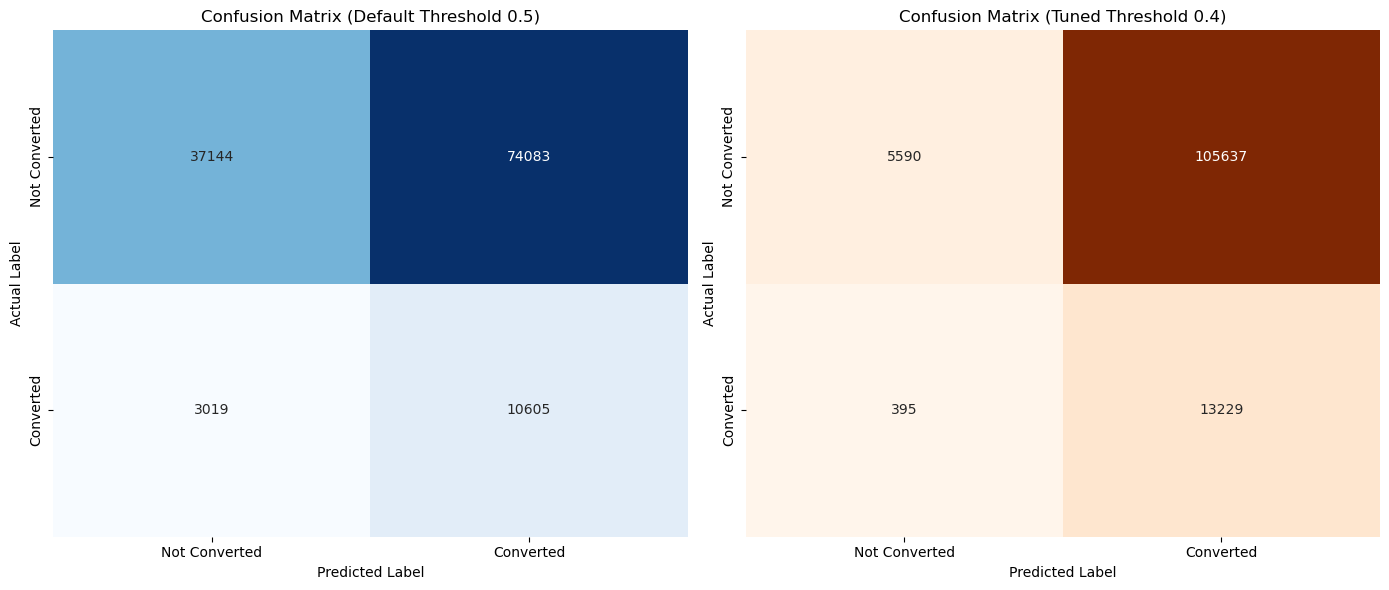

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- 1. GET ACTUALS AND PREDICTIONS --- 
# Grab the ground truth from your original validation dataframe
y_actual = df_pred['target']

# Grab the default predictions and probabilities from the results_df you just built
y_pred_default = results_df['predicted_class']
y_proba = results_df['conversion_probability']

# --- 2. SET A TUNED THRESHOLD (Optional but recommended) --- 
# Let's say you want to see how lowering the threshold impacts the matrix
threshold_tuned = 0.40
y_pred_tuned = (y_proba > threshold_tuned).astype(int)

# --- 3. CALCULATE THE MATRICES --- 
cm_default = confusion_matrix(y_actual, y_pred_default)
cm_tuned = confusion_matrix(y_actual, y_pred_tuned)

# --- 4. PLOT SIDE-BY-SIDE --- 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Default Threshold (0.5)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'], ax=axes[0])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')
axes[0].set_title('Confusion Matrix (Default Threshold 0.5)')

# Plot 2: Tuned Threshold (0.9)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'], ax=axes[1])
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')
axes[1].set_title(f'Confusion Matrix (Tuned Threshold {threshold_tuned})')

plt.tight_layout()
plt.show()

In [63]:
13354/124851

0.10695949571889693

In [64]:
892/(892+12034)

0.06900820052607148

In [65]:
import numpy as np
import pandas as pd

def predict_leads(df_pred, model, X_train_columns, cat_cols, target_percentile=25):
    """
    Generate predictions for new leads.
    
    Parameters:
    -----------
    df_pred : pd.DataFrame
        New leads data with same columns as training df
    model : CatBoostClassifier
        Trained model from train_bottom_decile_optimized()
    X_train_columns : list
        Column order from training (use X_train.columns)
    cat_cols : list
        Categorical columns from training
    target_percentile : int
        Your rejection threshold (e.g., 25 for bottom 25%)
    
    Returns:
    --------
    results_df : pd.DataFrame
        Original data + predictions + recommended actions
    """
    
    # ============================================
    # STEP 1: PREPARE FEATURES
    # ============================================
    print("Preparing features...")
    
    # Keep a copy of identifiers
    results_df = pd.DataFrame()
    
    if 'order_id' in df_pred.columns:
        results_df['order_id'] = df_pred['order_id'].values
    if 'request_datetime' in df_pred.columns:
        results_df['request_datetime'] = df_pred['request_datetime'].values
    if 'seller_name' in df_pred.columns:
        results_df['seller_name'] = df_pred['seller_name'].values
    
    # Drop non-feature columns (same as training)
    cols_to_drop = ['label', 'target', 'order_id', 'request_datetime']
    X_new = df_pred.drop(columns=[c for c in cols_to_drop if c in df_pred.columns])
    
    # ============================================
    # STEP 2: HANDLE CATEGORICALS (same as training)
    # ============================================
    for col in cat_cols:
        if col in X_new.columns:
            X_new[col] = X_new[col].fillna('unknown').astype(str).str.strip()
    
    # ============================================
    # STEP 3: ENFORCE COLUMN ORDER (critical!)
    # ============================================
    # Must match training exactly
    missing_cols = set(X_train_columns) - set(X_new.columns)
    extra_cols = set(X_new.columns) - set(X_train_columns)
    
    if missing_cols:
        print(f"⚠️  Missing columns (filling with defaults): {missing_cols}")
        for col in missing_cols:
            X_new[col] = 'unknown' if col in cat_cols else -1
    
    if extra_cols:
        print(f"⚠️  Extra columns (dropping): {extra_cols}")
        X_new = X_new.drop(columns=list(extra_cols))
    
    X_new = X_new[X_train_columns]
    
    # ============================================
    # STEP 4: GENERATE PREDICTIONS
    # ============================================
    print("Generating predictions...")
    
    # Probability of conversion (class 1)
    conversion_proba = model.predict_proba(X_new)[:, 1]
    
    # Threshold for rejection (bottom X%)
    rejection_threshold = np.percentile(conversion_proba, target_percentile)
    
    # ============================================
    # STEP 5: BUILD RESULTS
    # ============================================
    results_df['conversion_probability'] = conversion_proba
    
    # Percentile rank (0 = worst, 100 = best)
    results_df['percentile_rank'] = pd.Series(conversion_proba).rank(pct=True) * 100
    
    # Recommended action
    results_df['recommended_action'] = np.where(
        conversion_proba <= rejection_threshold,
        'REJECT',
        'ACCEPT'
    )
    
    # Confidence tier
    results_df['confidence_tier'] = pd.cut(
        results_df['percentile_rank'],
        bins=[0, 10, 25, 50, 75, 100],
        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
    )
    
    # ============================================
    # STEP 6: SUMMARY STATS
    # ============================================
    n_total = len(results_df)
    n_reject = (results_df['recommended_action'] == 'REJECT').sum()
    n_accept = (results_df['recommended_action'] == 'ACCEPT').sum()
    
    print(f"\\n{'='*50}")
    print("PREDICTION SUMMARY")
    print(f"{'='*50}")
    print(f"Total leads scored: {n_total:,}")
    print(f"Recommended REJECT: {n_reject:,} ({n_reject/n_total:.1%})")
    print(f"Recommended ACCEPT: {n_accept:,} ({n_accept/n_total:.1%})")
    print(f"Rejection threshold: {rejection_threshold:.4f}")
    print(f"{'='*50}")
    
    return results_df


# ============================================
# USAGE
# ============================================

# Run predictions
results = predict_leads(
    df_pred=df_pred,
    model=best_model,
    X_train_columns=X_train.columns.tolist(),  # From training
    cat_cols=cat_cols,                          # From training
    target_percentile=25                        # Your target
)

# View results
print("\\nSample predictions:")
print(results.head(10))

Preparing features...
⚠️  Extra columns (dropping): {'consent_marketing_email', 'finance_current_unsecured_debt_amount'}
Generating predictions...
\n==================================================
PREDICTION SUMMARY
Total leads scored: 124,851
Recommended REJECT: 31,213 (25.0%)
Recommended ACCEPT: 93,638 (75.0%)
Rejection threshold: 0.0891
\nSample predictions:
     order_id    request_datetime seller_name  conversion_probability  \
0        -1.0 2026-02-23 00:00:18          ZP                0.203708   
1        -1.0 2026-02-23 00:00:23          ZP                0.079241   
2        -1.0 2026-02-23 00:00:25          ZP                0.055723   
3        -1.0 2026-02-23 00:00:45          ZP                0.095582   
4        -1.0 2026-02-23 00:00:47          ZP                0.087339   
5        -1.0 2026-02-23 00:00:57        Bume                0.107117   
6  56229055.0 2026-02-23 00:00:58        Bume                0.080051   
7        -1.0 2026-02-23 00:01:02        Bume    

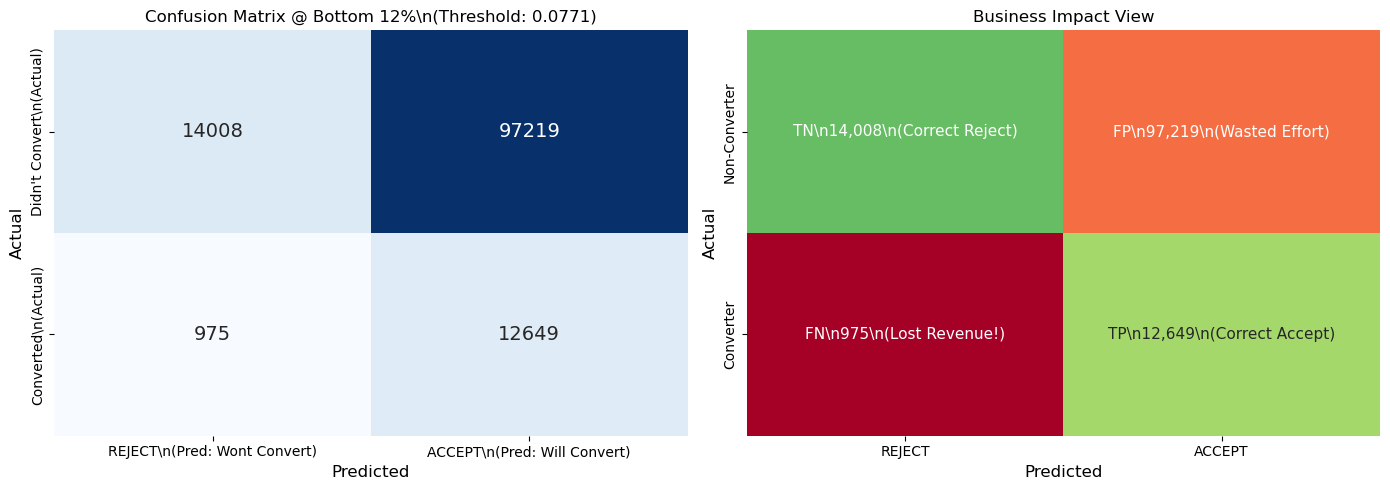

\n============================================================
CONFUSION MATRIX SUMMARY @ Bottom 12%
\n-------------------REJECTION PERFORMANCE--------------------
  Leads rejected: 14,983 (12.0% of total)
  True Negatives (correct rejections): 14,008
  False Negatives (converters lost): 975
  Rejection Precision: 93.49%
  False Negative Rate: 6.51%
\n-------------------ACCEPTANCE PERFORMANCE-------------------
  Leads accepted: 109,868 (88.0% of total)
  True Positives (correct accepts): 12,649
  False Positives (wasted effort): 97,219
\n--------------------------OVERALL---------------------------
  Total leads: 124,851
  AUC: 0.5986
  Actual conversion rate: 10.91%


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

def plot_confusion_matrix(results_df, df_pred, target_percentile=20):
    """
    Generate confusion matrices for the validation dataset.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        Output from predict_leads()
    df_pred : pd.DataFrame
        Validation data with actual labels
    target_percentile : int
        Your rejection threshold (e.g., 25 for bottom 25%)
    """
    
    # ============================================
    # STEP 1: GET ACTUAL LABELS
    # ============================================
    if 'target' in df_pred.columns:
        y_actual = df_pred['target'].values
    elif 'label' in df_pred.columns:
        df_pred['label'] = df_pred['label'].astype(str).str.strip().str.lower()
        y_actual = df_pred['label'].map({'converted': 1, 'not_converted': 0}).values
    else:
        raise ValueError("df_pred must have 'target' or 'label' column")
    
    # ============================================
    # STEP 2: GET PREDICTIONS
    # ============================================
    y_proba = results_df['conversion_probability'].values
    
    # Threshold based on target percentile
    threshold = np.percentile(y_proba, target_percentile)
    
    # Predicted: 0 = REJECT (won't convert), 1 = ACCEPT (will convert)
    y_pred = np.where(y_proba <= threshold, 0, 1)
    
    # ============================================
    # STEP 3: CONFUSION MATRIX
    # ============================================
    # Note: We're predicting NON-CONVERSION, so:
    #   - True Negative (TN): Predicted REJECT, Actually didn't convert ✓
    #   - False Negative (FN): Predicted REJECT, Actually converted ✗ (lost revenue!)
    #   - False Positive (FP): Predicted ACCEPT, Actually didn't convert
    #   - True Positive (TP): Predicted ACCEPT, Actually converted ✓
    
    cm = confusion_matrix(y_actual, y_pred)
    
    # Extract values
    tn, fp, fn, tp = cm.ravel()
    
    # ============================================
    # STEP 4: CALCULATE METRICS
    # ============================================
    total = len(y_actual)
    n_rejected = (y_pred == 0).sum()
    n_accepted = (y_pred == 1).sum()
    
    # Precision on rejections: when we reject, how often are we right?
    rejection_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    # False negative rate among rejections
    fn_rate = fn / (tn + fn) if (tn + fn) > 0 else 0
    
    # Overall AUC
    auc = roc_auc_score(y_actual, y_proba)
    
    # ============================================
    # STEP 5: PLOT
    # ============================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ----- Plot 1: Standard Confusion Matrix -----
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=['REJECT\\n(Pred: Wont Convert)', 'ACCEPT\\n(Pred: Will Convert)'],
        yticklabels=['Didn\'t Convert\\n(Actual)', 'Converted\\n(Actual)'],
        ax=axes[0],
        cbar=False,
        annot_kws={'size': 14}
    )
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('Actual', fontsize=12)
    axes[0].set_title(f'Confusion Matrix @ Bottom {target_percentile}%\\n(Threshold: {threshold:.4f})', fontsize=12)
    
    # ----- Plot 2: Annotated Confusion Matrix -----
    labels = np.array([
        [f'TN\\n{tn:,}\\n(Correct Reject)', f'FP\\n{fp:,}\\n(Wasted Effort)'],
        [f'FN\\n{fn:,}\\n(Lost Revenue!)', f'TP\\n{tp:,}\\n(Correct Accept)']
    ])
    
    colors = np.array([
        [0.2, 0.8],  # TN=good(green), FP=okay(light)
        [1.0, 0.3]   # FN=bad(red), TP=good(green)
    ])
    
    sns.heatmap(
        colors,
        annot=labels,
        fmt='',
        cmap='RdYlGn_r',
        xticklabels=['REJECT', 'ACCEPT'],
        yticklabels=['Non-Converter', 'Converter'],
        ax=axes[1],
        cbar=False,
        annot_kws={'size': 11},
        vmin=0,
        vmax=1
    )
    axes[1].set_xlabel('Predicted', fontsize=12)
    axes[1].set_ylabel('Actual', fontsize=12)
    axes[1].set_title('Business Impact View', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # STEP 6: PRINT METRICS
    # ============================================
    print(f"\\n{'='*60}")
    print(f"CONFUSION MATRIX SUMMARY @ Bottom {target_percentile}%")
    print(f"{'='*60}")
    
    print(f"\\n{'REJECTION PERFORMANCE':-^60}")
    print(f"  Leads rejected: {n_rejected:,} ({n_rejected/total:.1%} of total)")
    print(f"  True Negatives (correct rejections): {tn:,}")
    print(f"  False Negatives (converters lost): {fn:,}")
    print(f"  Rejection Precision: {rejection_precision:.2%}")
    print(f"  False Negative Rate: {fn_rate:.2%}")
    
    print(f"\\n{'ACCEPTANCE PERFORMANCE':-^60}")
    print(f"  Leads accepted: {n_accepted:,} ({n_accepted/total:.1%} of total)")
    print(f"  True Positives (correct accepts): {tp:,}")
    print(f"  False Positives (wasted effort): {fp:,}")
    
    print(f"\\n{'OVERALL':-^60}")
    print(f"  Total leads: {total:,}")
    print(f"  AUC: {auc:.4f}")
    print(f"  Actual conversion rate: {y_actual.mean():.2%}")
    print(f"{'='*60}")
    
    return {
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'rejection_precision': rejection_precision,
        'fn_rate': fn_rate,
        'auc': auc
    }


# ============================================
# RUN IT
# ============================================
metrics = plot_confusion_matrix(results, df_pred, target_percentile=12)

In [67]:
15264/124851

0.12225773121560901

In [68]:
967/(1995+10884)

0.07508346921344825

# Evaluation

In [70]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. Create a DataFrame with the test data results
fragment_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Predicted_Proba': model.predict_proba(X_test)[:, 1],
    'Price': X_test['seller_name'].values
})

print("AUC Scores by Exact Seller Minimum Price:\n" + "-"*50)

# 2. Group directly by the unique Price values instead of bucketing 
for price_val, group in fragment_df.groupby('Price'):
    
    converted_count = group['Actual_Label'].sum()
    total_count = len(group)
    
    # We must check if the fragment has both 0s and 1s, otherwise AUC throws an error
    if len(group['Actual_Label'].unique()) > 1:
        bucket_auc = roc_auc_score(group['Actual_Label'], group['Predicted_Proba'])
        
        print(f"Price Point: {price_val}")
        print(f"  -> AUC Score: {bucket_auc:.4f}")
        print(f"  -> Total rows: {total_count} (Converted: {converted_count})")
        print("-" * 50)
    else:
        print(f"Price Point: {price_val}")
        print(f"  -> Cannot calculate AUC (Needs both classes to calculate separation)")
        print(f"  -> Total rows: {total_count} (Converted: {converted_count})")
        print("-" * 50)

AUC Scores by Exact Seller Minimum Price:
--------------------------------------------------
Price Point: Bume
  -> AUC Score: 0.5703
  -> Total rows: 9787 (Converted: 901)
--------------------------------------------------
Price Point: PingYo
  -> AUC Score: 0.5934
  -> Total rows: 1981 (Converted: 163)
--------------------------------------------------
Price Point: ZP
  -> AUC Score: 0.5856
  -> Total rows: 38232 (Converted: 5761)
--------------------------------------------------


In [71]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. Create a DataFrame with the test data results
fragment_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Predicted_Proba': model.predict_proba(X_test)[:, 1],
    'age': X_test['age'].values
})

# 2. Fragment the prices into 4 equal-sized buckets (Quartiles)
# You can change q=4 to q=5 or q=10 if you want more granular fragments
fragment_df['age_segmanet'] = pd.qcut(fragment_df['age'], q=8, duplicates='drop')

print("AUC Scores by Seller Minimum Price Fragment:\n" + "-"*50)

# 3. Calculate and print the AUC for each fragment
for bucket, group in fragment_df.groupby('age_segmanet'):
    
    # We must check if the fragment has both 0s and 1s, otherwise AUC throws an error
    if len(group['Actual_Label'].unique()) > 1:
        bucket_auc = roc_auc_score(group['Actual_Label'], group['Predicted_Proba'])
        converted_count = group['Actual_Label'].sum()
        total_count = len(group)
        
        print(f"Price Range {bucket}:")
        print(f"  -> AUC Score: {bucket_auc:.4f}")
        print(f"  -> Total rows: {total_count} (Converted: {converted_count})")
        print("-" * 50)
    else:
        print(f"Price Range {bucket}: Cannot calculate AUC (only 1 class present in this bucket)")

AUC Scores by Seller Minimum Price Fragment:
--------------------------------------------------
Price Range (17.999, 30.0]:
  -> AUC Score: 0.6115
  -> Total rows: 6745 (Converted: 1311)
--------------------------------------------------
Price Range (30.0, 37.0]:
  -> AUC Score: 0.5832
  -> Total rows: 6862 (Converted: 1060)
--------------------------------------------------
Price Range (37.0, 42.0]:
  -> AUC Score: 0.6005
  -> Total rows: 6134 (Converted: 870)
--------------------------------------------------
Price Range (42.0, 46.0]:
  -> AUC Score: 0.5523
  -> Total rows: 5364 (Converted: 716)
--------------------------------------------------
Price Range (46.0, 52.0]:
  -> AUC Score: 0.5879
  -> Total rows: 7093 (Converted: 855)
--------------------------------------------------
Price Range (52.0, 57.0]:
  -> AUC Score: 0.5690
  -> Total rows: 5642 (Converted: 610)
--------------------------------------------------
Price Range (57.0, 64.0]:
  -> AUC Score: 0.5712
  -> Total rows: 

/var/folders/46/cr7dgrkj6wg5rb247mcvnzz40000gp/T/ipykernel_22851/2516196116.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, group in fragment_df.groupby('age_segmanet'):


Generating SHAP Summary Plot...


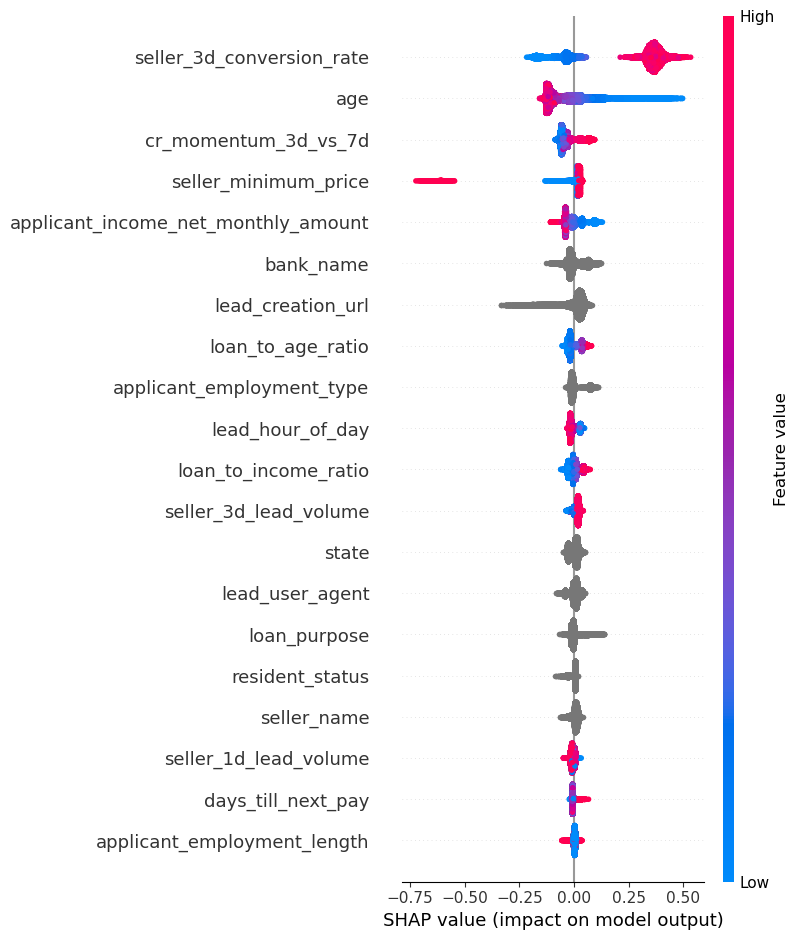

In [91]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the SHAP Explainer
# TreeExplainer is heavily optimized for CatBoost and XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# --- 1. GLOBAL INTERPRETABILITY (Summary) ----- 
print("Generating SHAP Summary Plot...")
# This shows every prediction. 
# Red = High feature value, Blue = Low feature value.
# Right of center = Pushes prediction towards 'converted'
shap.summary_plot(shap_values, X_test)


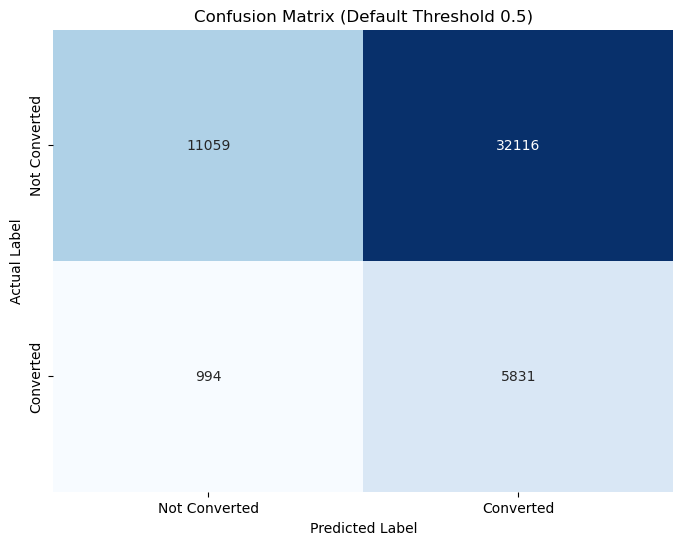

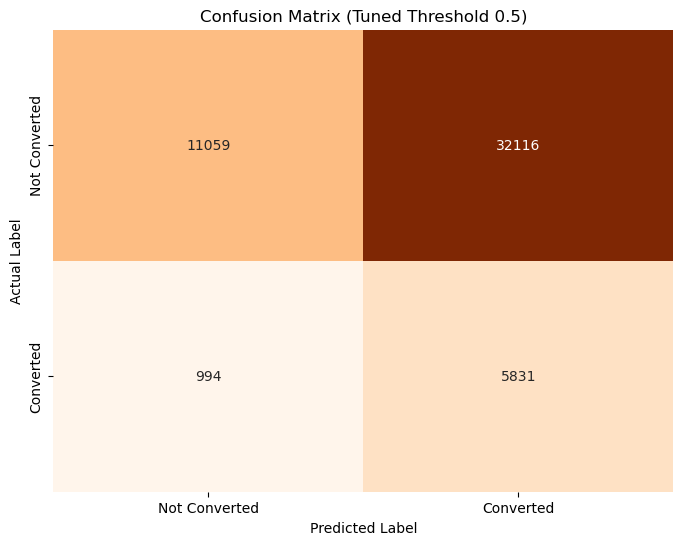

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get Predictions
# Standard predictions (0 or 1 based on > 0.5 probability)
y_pred = model.predict(X_test)

# Probability predictions (0.0 to 1.0) - needed for tuning
y_proba = model.predict_proba(X_test)[:, 1]

# --- PLOT 1: STANDARD CONFUSION MATRIX (Threshold = 0.5) ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Default Threshold 0.5)')
plt.show()

# --- PLOT 2: TUNED THRESHOLD MATRIX (e.g., Threshold = 0.3) ---
# Since AUC is 0.65, we might need to lower the bar to catch positives
threshold = 0.50  # Experiment with this number!
y_pred_tuned = (y_proba > threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix (Tuned Threshold {threshold})')
plt.show()

In [74]:
# (We are using your y_pred_tuned here, but you can swap it for y_pred if you prefer the default 0.5 threshold)

fn_mask = (y_test == 1) & (y_pred_tuned == 0)



# 2. Apply the mask to y_test to isolate just those rows, and grab their original indices

fn_indices = y_test[fn_mask].index



# 3. Use those indices to pull the 'order_id' straight from your original dataset (df)

# NOTE: Make sure your column name exactly matches 'order_id'

false_negative_orders = df.loc[fn_indices, 'order_id'].to_list()

len(false_negative_orders)

994

In [75]:
# 1. Create a mask: Actual was 1 (Converted) AND Predicted was 0 (Not Converted)
# We are using 'y_actual' and 'y_pred_tuned' straight from your confusion matrix block
fn_mask = (y_actual == 1) & (y_pred_tuned == 0)

# 2. Apply the mask directly to your validation dataframe (df_pred) 
# This isolates those specific rows and pulls out the 'order_id' column as a list
false_negative_orders = df_pred.loc[fn_mask, 'order_id'].tolist()

# 3. Verify the output
print(f"Total False Negatives (at {threshold_tuned} threshold): {len(false_negative_orders)}")
print(f"Sample False Negative Order IDs: {false_negative_orders[:5]}")

ValueError: operands could not be broadcast together with shapes (124851,) (50000,) 

In [ ]:
sql_formatted_ids = ", ".join([str(int(order_id)) for order_id in false_negative_orders if pd.notna(order_id)])

In [ ]:
len(sql_formatted_ids)

In [ ]:
revenue_lost_query = f"""
SELECT 
    cascade_type,
    count(distinct order_id)
FROM 
    DBT_PROD.ANALYTICS.FCT_TRANSACTION_INVOICE_ORDER_ITEM
WHERE 
    order_id IN ({sql_formatted_ids})
--and is_sale != 1
group by 1;
"""

In [ ]:
with engine.connect() as con:
    con.execute(text("use database dbt_prod"))
    casc_breakdown = pd.read_sql(revenue_lost_query, con)

In [ ]:
casc_breakdown

In [ ]:
1-(295/(295+231+273+217))

In [ ]:
1-(275/(185+273+168+263))

In [ ]:
revenue_lost

In [ ]:
# 1. Create a mask: Actual was 1 (Converted) AND Predicted was 0 (Not Converted)
# (We are using your y_pred_tuned here, but you can swap it for y_pred if you prefer the default 0.5 threshold)
tn_mask = (y_test == 0) & (y_pred_tuned == 0)

# 2. Apply the mask to y_test to isolate just those rows, and grab their original indices
tn_indices = y_test[tn_mask].index

# 3. Use those indices to pull the 'order_id' straight from your original dataset (df)
# NOTE: Make sure your column name exactly matches 'order_id'
false_negative_orders = df.loc[tn_indices, 'seller_name']
false_negative_orders

In [ ]:
df_time = expanded[['request_datetime','state', 'target']]

In [ ]:
import pandas as pd
import pytz

# 1. The State-to-Timezone Mapping Dictionary
# (Note: Assumes 2-letter state abbreviations. If your data uses full names, let me know!)
state_tz_map = {
    # Eastern
    'CT': 'America/New_York', 'DE': 'America/New_York', 'FL': 'America/New_York', 
    'GA': 'America/New_York', 'IN': 'America/New_York', 'ME': 'America/New_York', 
    'MD': 'America/New_York', 'MA': 'America/New_York', 'MI': 'America/New_York', 
    'NH': 'America/New_York', 'NJ': 'America/New_York', 'NY': 'America/New_York', 
    'NC': 'America/New_York', 'OH': 'America/New_York', 'PA': 'America/New_York', 
    'RI': 'America/New_York', 'SC': 'America/New_York', 'VT': 'America/New_York', 
    'VA': 'America/New_York', 'WV': 'America/New_York', 'DC': 'America/New_York',
    # Central
    'AL': 'America/Chicago', 'AR': 'America/Chicago', 'IL': 'America/Chicago', 
    'IA': 'America/Chicago', 'KS': 'America/Chicago', 'KY': 'America/Chicago', 
    'LA': 'America/Chicago', 'MN': 'America/Chicago', 'MS': 'America/Chicago', 
    'MO': 'America/Chicago', 'NE': 'America/Chicago', 'ND': 'America/Chicago', 
    'OK': 'America/Chicago', 'SD': 'America/Chicago', 'TN': 'America/Chicago', 
    'TX': 'America/Chicago', 'WI': 'America/Chicago',
    # Mountain
    'AZ': 'America/Phoenix', # AZ doesn't observe Daylight Saving Time!
    'CO': 'America/Denver', 'ID': 'America/Denver', 'MT': 'America/Denver', 
    'NM': 'America/Denver', 'UT': 'America/Denver', 'WY': 'America/Denver',
    # Pacific
    'CA': 'America/Los_Angeles', 'NV': 'America/Los_Angeles', 
    'OR': 'America/Los_Angeles', 'WA': 'America/Los_Angeles',
    # Others
    'AK': 'America/Anchorage', 'HI': 'Pacific/Honolulu'
}

print("Converting timestamps to local state time...")

# 2. Map the timezone string to each row
# If a state is missing or invalid, we default to Los_Angeles (PST) to prevent errors
expanded['target_tz'] = expanded['state'].str.upper().map(state_tz_map).fillna('America/Los_Angeles')

# 3. Ensure your base datetime is actually recognized as PST (Now DST-Proof!)
if expanded['request_datetime'].dt.tz is None:
    
    # Create an array of 'True' to force Pandas to treat the ambiguous hour as DST
    is_dst = np.ones(len(expanded), dtype=bool)
    
    # Localize using our new DST rules
    expanded['request_datetime'] = expanded['request_datetime'].dt.tz_localize(
        'America/Los_Angeles', 
        ambiguous=is_dst,             # Fixes the Fall Back duplicate hour
        nonexistent='shift_forward'   # Fixes the Spring Forward missing hour
    )

# 4. The "Fast GroupBy" Conversion Trick
local_times = []
for tz, group in expanded.groupby('target_tz'):
    # Convert the chunk to the state's timezone, then immediately strip the TZ info (tz_localize(None))
    converted_chunk = group['request_datetime'].dt.tz_convert(tz).dt.tz_localize(None)
    local_times.append(converted_chunk)

# 5. Stitch it all back together and assign it to a new column
expanded['local_request_datetime'] = pd.concat(local_times)

# 6. Drop the temporary helper column
expanded = expanded.drop(columns=['target_tz'])

print("Done! Here is a sample of the conversion:")
print(expanded[['state', 'request_datetime', 'local_request_datetime']].head(10))

In [ ]:
expanded[['state', 'request_datetime', 'local_request_datetime','target']]

In [ ]:
expanded['local_lead_hour_of_day'] = expanded['local_request_datetime'].dt.hour

In [ ]:
expanded[['local_lead_hour_of_day','state', 'target']].groupby(by = 'local_lead_hour_of_day').agg({
    'state':'count',
    'target':'sum'
}).to_csv('/Users/amanda.huang/Downloads/hourly_leads_conversion_local.csv', index=True)